# Denoising and regularization: `rgz` and `cdf` modules

> **NOTE:** This tutorial assumes familiarity with the concepts explained in  [Conceptual and mathematical background of higher-order Fourier analysis](concept-background) and that the ``HoFa`` package has already been installed, see [Installation](../getting_started/installation).

> **HOW TO READ THIS NOTEBOOK:** This notebook starts from a simplified version of the algorithm and progressively introduces the full generality of the implementation. Readers interested only in usage may skip to [How the algorithm is implemented in practice](#denoising--how-the-algorithm-is-implemented), while readers interested in design choices may follow the full narrative.

In this notebook we discuss how the ``HoFa`` package removes $U^k$ noise from a function, and we explain the implementation details of the regularization algorithm. 

## The algorithm: a minimal but representative formulation

We begin by presenting the algorithm in a deliberately restricted form. This version captures the full logical structure of the method while avoiding additional choices and tunable components that, although important in practice, are not essential for understanding how the algorithm works. The general implementation provided by the package follows the same core steps and introduces further flexibility only where meaningful alternatives arise. By starting from this minimal formulation, we can focus on the underlying mechanism of the algorithm before discussing how it can be extended, customized, and optimized.

Throughout this section, it is useful to keep in mind that every component introduced here has a direct counterpart in the full implementation. Later sections will revisit each step and show how it can be modified or replaced to accommodate different variants of the algorithm.

Let us recall below with pseudocode the basic version we are interested in.

<a id="basic-regularization"></a>**Basic** $U^3$ **regularization algorithm**

_Input:_ $f: Z \to \mathbb{C}$, $\rho, \varepsilon {>0}$

1. $M \leftarrow f \otimes \overline{f} \in \mathbb{C}^{Z \times Z}$

2. For each $t \in Z$:
    - $M(\cdot + t, \cdot) \leftarrow K_\varepsilon(M(\cdot + t, \cdot))$

3. $(\mu_1, v_1), \ldots, (\mu_{|Z|}, v_{|Z|}) \leftarrow \mathrm{Eigdecomp}(M)$ 


_Output:_ $f_{\text{reg}} \leftarrow\sum_{\mu_i \ge \rho} \langle f, v_i \rangle v_i$, eigenvalues $\leftarrow \{\mu_1,\ldots, \mu_{|Z|}\}$, and eigenvectors $\leftarrow \{v_{1},\ldots, v_{|Z|}\}$.

To understand better how the algorithm works, we now walk through its basic formulation step by step on a simple example. By explicitly computing the intermediate quantities, we expose the internal logic that is otherwise hidden by the implementation. This perspective will be useful when we later introduce more general variants of the algorithm.

## Manual execution of the basic algorithm

We consider the following illustrative problem, which will serve as a running example throughout this section.

<a id="denoising--problem-statement"></a>
### Problem statement

We want to transmit the periodic linear chirp $f_s(x)=\sin(2\pi x^2/n)$ defined for any integer $x$ (note the periodicity property $f_s(x+n)=f_s(x)$). However, our communication channel introduces noise, and what is received is a convex combination $f=tf_r+(1-t)f_s$ where $f_r(x)$ follows a uniform distribution $\text{Unif}([-1,1))$ independently for every integer $x$ and the amount of noise is $t=30$%.

This intentionally simple formulation is chosen to highlight the core behavior of the algorithm, rather than edge cases.

### Objective

Under these assumptions, we aim to compute an estimate of $f_s$.

In what follows, we use this example to execute the algorithm step by step manually, making explicit the intermediate quantities involved in the computation.

First of all, let us import the necessary modules. Recall that we are assuming that the ``HoFa`` package is already installed, see [Installation](../getting_started/installation). For a quick installation, run the following command:

```console
(hofavenv) $ pip install hofa
```

In [1]:
# Import the necessary packages to use hofa
import hofa.cdf as cdf
import hofa.rgz as rgz

# and visualize its results
import numpy as np
np.set_printoptions(precision=2)
import matplotlib.pyplot as plt
import scipy

### Modeling the problem

**Setup:**

* $f_s(x):\mathbb{Z}\to \mathbb{R}$ is defined as $x\mapsto \sin(2\pi x^2/n)$,
* $f_r:\mathbb{Z}\to \mathbb{R}$ is defined as $f_r(x)\sim \text{Unif}([-1,1))$ independently for every $x\in \mathbb{Z}$,
* $f:=t f_r+(1-t)f_s$ for $t=0.3$.

**Goal:** Recover $f_s$ using only $f$.

In [2]:
n = 173 # Feel free to change this
x = np.arange(n)
f_s = np.sin(2*np.pi*x**2/n)
# Due to implementation reasons of auxiliary functions, 
# it is convenient to work with complex numbers
f_s = f_s.astype(complex) 

# For reproducibility reasons, we fix a random seed, but feel free to change this.
np.random.seed(123)
f_r = np.random.uniform(-1, 1, size=len(x))

# And finally we construct the only function we are going to work with, f.
# To do that, we fix t=0.3, but again, feel free to change it and test the limits of the algorithm.
t = 0.3
f = t*f_r+(1-t)*f_s

### The algorithm step by step

Now that we have defined our function, it is time to implement the [basic $U^3$ regularization algorithm](#basic-regularization). The first step is to compute the matrix $f\otimes \overline{f}$. The module `rgz` provides us with the method `hofa.rgz.t_prod_itself` to do so.

In [3]:
M = rgz.t_prod_itself(f) # We compute the matrix
M[:5,:5] # And we visualize only the first 5x5 upper left corner

array([[ 0.01+0.j, -0.01-0.j, -0.01-0.j,  0.03+0.j,  0.06+0.j],
       [-0.01+0.j,  0.01+0.j,  0.01+0.j, -0.03+0.j, -0.05+0.j],
       [-0.01+0.j,  0.01+0.j,  0.  +0.j, -0.02+0.j, -0.03+0.j],
       [ 0.03+0.j, -0.03-0.j, -0.02-0.j,  0.07+0.j,  0.13+0.j],
       [ 0.06+0.j, -0.05-0.j, -0.03-0.j,  0.13+0.j,  0.27+0.j]])

We see that the result is a real symmetric matrix $M_{n\times n}(\mathbb{R})$. In general, if the map $f$ takes complex values then the resulting matrix will be self-adjoint.

The second step in the [basic $U^3$ regularization algorithm](#basic-regularization) consists in changing each $Z$-diagonal of $M$ to a _Fourier regularized version_. Note that the $Z$-diagonals are not the usual diagonals of a matrix, indeed they are defined using modular arithmetic. That is, if $M=(m_{i,j})_{i,j=0,\ldots,n-1}$ , for $t=0,\ldots,n-1$ the $Z$-diagonal at height $t$ consists of the entries $m_{i,j}$ such that $i-j$ equal the same integer $t$ **modulo $n$**. This part is important, so let us draw a diagram where we highlight the different diagonals. For simplicity, suppose for now that $n=6$ (instead of $n=173$ as we have above), so the matrix $M$ is 6x6. Then its $Z$-diagonals are as follows.

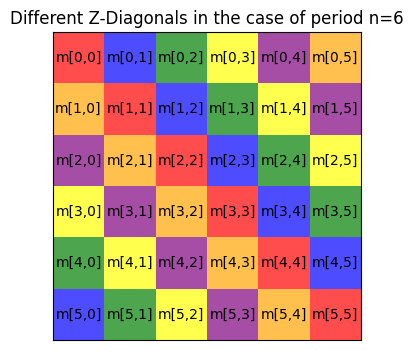

In [4]:
from matplotlib.colors import ListedColormap, BoundaryNorm

matrix = np.array([
    [0, 1, 2, 3, 4, 5],
    [5, 0, 1, 2, 3, 4],
    [4, 5, 0, 1, 2, 3],
    [3, 4, 5, 0, 1, 2],
    [2, 3, 4, 5, 0, 1],
    [1, 2, 3, 4, 5, 0]
])

colors = ["red", "blue", "green", "yellow", "purple", "orange"]

cmap = ListedColormap(colors)
norm = BoundaryNorm(np.arange(-0.5, 6.5, 1), cmap.N)

plt.figure(figsize=(4, 4))
plt.imshow(matrix, cmap=cmap, norm=norm, alpha=0.7)
plt.xticks([])
plt.yticks([])

for i in range(6):
    for j in range(6):
        plt.text(j, i, 'm['+str(i)+','+str(j)+']',
                 ha="center", va="center", color="black")

plt.title('Different Z-Diagonals in the case of period n=6')
plt.show()

There are many ways of operating on the $Z$-diagonals of a matrix, but currently there is no fast `numpy` or `scipy` method that can vectorize an operation through these diagonals. The solution given in `hofa.rgz` is to define an auxiliary matrix where the $Z$-diagonals of a function are moved to the rows using `hofa.rgz.move_diag_to_rows`, so that we can operate with them easily, and then a function to put them back in their original positions `hofa.rgz.move_rows_to_diag`. Let us see these methods in action on our toy example:

In [5]:
M_diag_to_rows = rgz.move_diag_to_rows(M)
M_diag_to_rows[:5,:5]

array([[ 0.01+0.j,  0.01+0.j,  0.  +0.j,  0.07+0.j,  0.27+0.j],
       [-0.01-0.j,  0.01+0.j, -0.02+0.j,  0.13+0.j,  0.26+0.j],
       [-0.01-0.j, -0.03+0.j, -0.03+0.j,  0.13+0.j,  0.5 +0.j],
       [ 0.03+0.j, -0.05+0.j, -0.03+0.j,  0.25+0.j,  0.41+0.j],
       [ 0.06+0.j, -0.05+0.j, -0.06+0.j,  0.2 +0.j,  0.26+0.j]])

Note that, e.g., the main diagonal is now the first row in the `M_diag_to_rows` matrix.

To put it back to its original state, we can use `hofa.rgz.move_rows_to_diag`.

In [6]:
M_back_to_position = rgz.move_rows_to_diag(M_diag_to_rows)
print(f" All elements correctly reorganized: {np.all(M == M_back_to_position)}")

 All elements correctly reorganized: True


The actual implementations of both of these functions currently use [Broadcasting](https://numpy.org/doc/stable/user/basics.broadcasting.html) and [Advanced indexing](https://numpy.org/doc/2.2/user/basics.indexing.html#advanced-indexing), to handle not only the case of 1-dimensional $n$-periodic function but also the general case of any number of dimensions with different periods, see [Coding theory example](#denoising--coding-theory).

Recall, however, that what we want in the [basic $U^3$ regularization algorithm](#basic-regularization) is to create a new matrix where we have changed the $Z$-diagonals by applying the Fourier denoising operator $K_\varepsilon$. Remember that this operator uses a small constant $\varepsilon$ defined by the user, so let us fix one such constant and define the denoising operator $K_\varepsilon$.

In [7]:
epsilon = 0.03

def denoising_operator(diag : np.ndarray):
    """
    Modifies the function `diag` on the finite abelian group Z to produce K_epsilon(diag).

    Parameters:
        diag (function): The function defined on Z.

    Returns:
        function: The modified function K_epsilon(diag).
    """
    # Compute all Fourier coefficients of diag
    fourier_coeffs = np.fft.fftn(diag,norm="forward")

    # Modify Fourier coefficients as per the algorithm
    modified_coeffs = (np.maximum(np.abs(fourier_coeffs)-epsilon,0))*np.exp(1j*np.angle(fourier_coeffs))

    # Return the new function K_epsilon(diag) using the modified Fourier coefficients
    return np.fft.ifftn(modified_coeffs, norm="forward")

Now, we need to apply this operator on every $Z$-diagonal of our $Z$-matrix $M$. To do so, we have the method `hofa.rgz.apply_on_diag`. This method essentially uses `hofa.rgz.move_diag_to_rows` to put all diagonals as rows, applies an operator to each diagonal, and puts the diagonals back in their original places with `hofa.rgz.move_rows_to_diag`.

> **Note:** This is one of the places where performance could be enhanced by providing native methods written in C for handling $Z$-diagonals. Note that this process of applying an operator to every $Z$-diagonal can be parallelized (this may be done with a `PyTorch` implementation in a future development of this package).

In [8]:
M_diags_reg = rgz.apply_on_diag(M, denoising_operator)

# Similarly as before, we compute the same for our toy example M_g
M_g_diags_reg = rgz.apply_on_diag(M, denoising_operator)
M_g_diags_reg[:4,:4]

array([[0.21+2.78e-17j, 0.22-1.39e-17j, 0.21+6.94e-18j, 0.2 -2.78e-17j],
       [0.22+7.98e-17j, 0.24+9.45e-17j, 0.22+6.25e-17j, 0.21-5.20e-17j],
       [0.21+5.38e-17j, 0.22-6.25e-17j, 0.25-6.94e-18j, 0.21-4.16e-17j],
       [0.2 -1.39e-17j, 0.21+1.18e-16j, 0.21+4.86e-17j, 0.26-4.16e-17j]])

After this preprocessing of our matrix by these operations on its diagonals, we are ready to carry out the main step in the algorithm. Specifically, we now need to compute the eigendecomposition of $M$. 

> **Note**: We prefer to use a different normalization for eigenvalues and eigenvectors other than the one of `np.linalg.eigh`. The reason is that if we treat $M$ as a **kernel operator**, we should normalize the application of $M$ on a vector dividing by the length of the vector. That is, as a kernel operator $M$ applied on a vector $v$ should be defined as $\tfrac{1}{n}Mv$. This is consistent with e.g. normalizing the forward Fourier transform $\widehat{f}(\chi)=\tfrac{1}{n}\sum_{x=0}^{n-1} f(x)\overline{\chi(x)}$ as we always do in the ``HoFa`` package. In practive this means that we have to divide the eigenvalues resulting from `np.linalg.eigh` by $n$ and multiply the eigenvectors by $\sqrt{n}$ (so that they have norm 1 when we compute the normalized $L^2$ norm $\|f\|_2^2=\tfrac{1}{n}\sum_{x=0}^{n-1} |f(x)|^2$).

In [9]:
eivals, eivects = np.linalg.eigh(M_diags_reg)

# To normalize eigenvalues and eigenvectors we need to do
# the following
eivals = eivals/n
eivects = eivects*np.sqrt(n)

The critical phenomenon appears now when we look at the eigenvalues of `M_diags_reg`. Recall that these are given in increasing order.

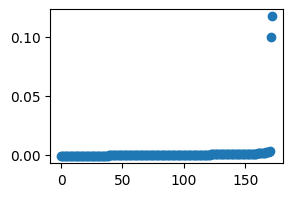

In [10]:
plt.figure(figsize=(3, 2))
plt.plot(eivals, marker='o', linestyle='None')
plt.show()

We clearly obtain two eigenvalues with absolute value significantly larger than the rest. The deep reason for this is that, with respect to this algorithm, we are seeing our function $f_s(x)=\sin(2\pi x^2/n)$ as a combination of two higher-order characters

$$\sin(2\pi x^2/n) = \frac{e^{2\pi i x^2/n}-e^{-2\pi i x^2/n}}{2i}.$$

> **Note:** we have computed this using only the given input function $f=tf_r+(1-t)f_s$, not the structured part $f_s$, and yet the algorithm has been able to recognize not only the quadratic structure, but also the fact that it comes from 2 _higher-order characters_.

Our [basic $U^3$ regularization algorithm](#basic-regularization) tells us that projecting the function $f$ to the eigenspace generated by the eigenvectors corresponding to these two eigenvalues keeps precisely the quadratic component of the function $f$.

In [11]:
# Now we compute the projection of f on that eigenvector
f_reg = np.mean(f*eivects[:,-1].conjugate())*eivects[:,-1]+np.mean(f*eivects[:,-2].conjugate())*eivects[:,-2]

To finish, let us plot this function together with the original function $f$, and also the true quadratic component $(1-t)f_s$ that is hidden within $f$.

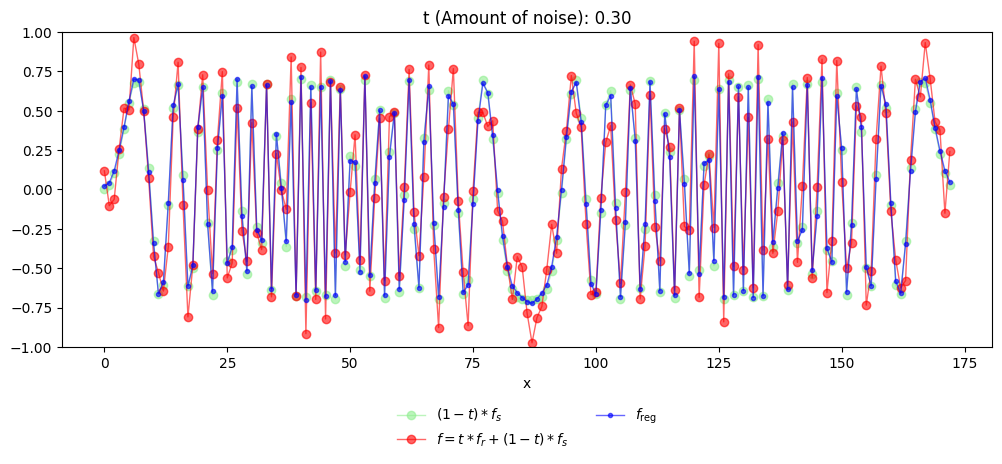

In [12]:
# And now let us print the original function f_s*(1-t), the modified version
# f, and the output of our algorithm f_reg. (For simplicity we only plot
# the real part of those functions).
fig, ax = plt.subplots(figsize=(12, 5))

# Plot original (1-t)*f_s in light green
ax.plot(x, np.real(f_s*(1-t)), linestyle='-', color='lightgreen', marker='o', markersize=6, linewidth=1, alpha=0.6, label=r'$(1-t)*f_s$')

# Plot modified function in red
ax.plot(x, np.real(f), linestyle='-', color='red', marker='o', markersize=6, linewidth=1, alpha=0.6, label=r'$f = t*f_r+(1-t)*f_s$')

# Plot recovered function in blue
ax.plot(x, np.real(f_reg), linestyle='-', color='blue', marker='o', markersize=3, linewidth=1, alpha=0.6, label=r'$f_{\text{reg}}$')

# Customize the plot
ax.set_xlabel("x")
ax.set_title(f"t (Amount of noise): {t:.2f}")
ax.set_ylim(-1,1)

# Legend below the plot
fig.subplots_adjust(bottom=0.25)  # Adjust layout to fit legend below
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=False)

# Show the plot
plt.show()

Before we continue, the reader is encouraged to modify the above example with different functions, parameters $\varepsilon,\rho, t, n$ etc. 

The sequence of operations we have just carried out manually is exactly what the package implements internally. In practice, all of the steps above are encapsulated in a single function call to ``hofa.rgz.regularize()``, which performs the same computation while handling the necessary bookkeeping and numerical details. Moreover, it includes heuristics to compute the parameters $\varepsilon,\rho$.

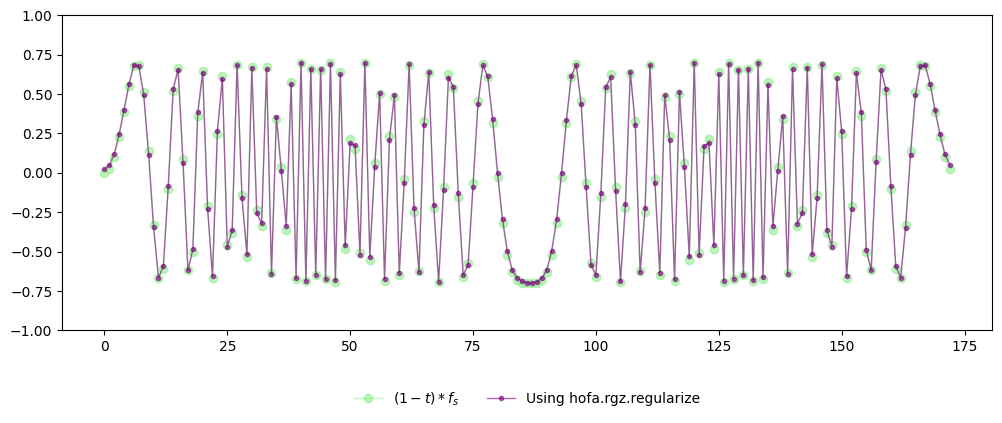

In [13]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(x, np.real(f_s*(1-t)), linestyle='-', color='lightgreen', marker='o', markersize=6, linewidth=1, alpha=0.6, label=r'$(1-t)*f_s$')

ax.plot(x, np.real(rgz.regularize(f,2).regularization), linestyle='-', color='purple', marker='o', markersize=3, linewidth=1, alpha=0.6, label=r'Using hofa.rgz.regularize')

ax.set_ylim(-1,1)
fig.subplots_adjust(bottom=0.25)  # Adjust layout to fit legend below
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=False)

plt.show()


<a id="denoising--generalizing-the-algorithm"></a>
### Generalizing the algorithm

While the basic formulation already captures the core idea of the algorithm, there are other reasonable ways to instantiate this idea. Several aspects of the procedure admit alternative choices, leading to variants that differ in behavior, robustness, or computational cost. The package is designed to expose these degrees of freedom in a controlled way, allowing users to adapt the algorithm to specific problems while preserving the underlying structure described above. Let us now discuss where these alternatives may take place by pinpointing in the [basic $U^3$ regularization algorithm](#basic-regularization) the possible variants.

_Input:_ $f: Z \to \mathbb{C}$, $\rho, \varepsilon {>0}$ <span style="border: 0px solid red; padding: 2px; display: inline-block; background-color: #f8d7da; border-radius: 5px; text-align: right; font-weight: bold;"> &#8594; 1 </span>

1. $M \leftarrow f \otimes \overline{f} \in \mathbb{C}^{Z \times Z}$

2. For each $t \in Z$:
    - $M(\cdot + t, \cdot) \leftarrow K_\varepsilon(M(\cdot + t, \cdot))$ <span style="border: 0px solid red; padding: 2px; display: inline-block; background-color: #f8d7da; border-radius: 5px; text-align: right; font-weight: bold;"> &#8594; 2 </span>

3. $(\mu_1, v_1), \ldots, (\mu_{|Z|}, v_{|Z|}) \leftarrow \mathrm{Eigdecomp}(M)$ <span style="padding: 2px; display: inline-block; background-color: #f8d7da; border-radius: 5px; text-align: right; font-weight: bold;"> &#8594; 3 </span>


_Output:_ $f_{\text{reg}} \leftarrow\sum_{\mu_i \ge \rho} \langle f, v_i \rangle v_i$, eigenvalues $\leftarrow \{\mu_1,\ldots, \mu_{|Z|}\}$, and eigenvectors $\leftarrow \{v_{1},\ldots, v_{|Z|}\}$.

<span style="border: 0px solid red; padding: 2px; display: inline-block; background-color: #f8d7da; border-radius: 5px; text-align: right; font-weight: bold;"> &#8594; 1 </span> How can we choose these parameters $\varepsilon$ and $\rho$?

<span style="border: 0px solid red; padding: 2px; display: inline-block; background-color: #f8d7da; border-radius: 5px; text-align: right; font-weight: bold;"> &#8594; 2 </span> So far we used the map ``denoising_operator`` for regularizing the diagonals, thus substituting each diagonal $g$ with $\sum \mathrm{ReLU}(|\widehat{g}(\chi)|-\varepsilon)\tfrac{\widehat{g}(\chi)}{|\widehat{g}(\chi)|}\chi$. But can we use other methods, such as simply $g \mapsto \sum_{|\widehat{g}(\chi)|\ge \varepsilon}\widehat{g}(\chi)\chi$ ? Moreover, what if we want to do cubic or higher-order regularizations? As explained in [Order increment principle, page 5, Figure 1](https://doi.org/10.1017/fms.2026.10238), for order $k$ regularization, we should replace $K_\varepsilon$ with a regularizer of order $k-1$. For instance, if we want $U^4$ (or cubic) regularization, we should replace $K_\varepsilon$ with the [Basic $U^3$ regularization algorithm](#basic-regularization) itself! 

<span style="border: 0px solid red; padding: 2px; display: inline-block; background-color: #f8d7da; border-radius: 5px; text-align: right; font-weight: bold;"> &#8594; 3 </span> Last but not least, we have to compute the eigendecomposition of a matrix. However, we are typically interested only in the largest eigenvalues and eigenvectors. Moreover, the number of required dominant eigenvalues depends on the cutoff parameter $\rho$. Hence, in general we do not want to compute the full eigendecomposition using `numpy.linalg.eigh`. Is there anything better?

All these question will be adressed below.

<a id="denoising--how-the-algorithm-is-implemented"></a>
## How the algorithm is implemented in practice

So far, we have explored the basic version of the algorithm and walked through its steps manually to build intuition. The version implemented in the package follows the same core logic but adds flexibility and tunable components that allow it to handle a wider range of practical scenarios.  

Let us now present the **full algorithm** in pseudocode and explain how its different parts are implemented. We start with the main function that encapsulates the internal logic, then describe auxiliary functions and classes that provide additional control for advanced users. 

To understand this pseudocode, recall that this is a **recursive** algorithm. Let us denote by $K(f,k)$ the output of the order-$k$ regularization algorithm applied to a function $f$.

<a id="general-regularization"></a>**General** $U^k$ **regularization algorithm**

_Input:_ Function to regularize: $f: Z \to \mathbb{C}$ and order of regularization: $k$ (a positive integer)

0. If $k==1$:

    _Output_: $K(f,1)$: Fourier regularization on $f$, absolute value squared of Fourier coefficients $|\widehat{f}(\chi)|^2$, and all Fourier characters $\{\chi\}$.

2. $M \leftarrow f \otimes \overline{f} \in \mathbb{C}^{Z \times Z}$

3. For each $t \in Z$:
    - Replace the $Z$-diagonal $M(\cdot + t, \cdot)$ with its order-$(k-1)$ regularization $K((M(\cdot + t, \cdot),k-1)$.

4. $(\mu_1, v_1), \ldots, (\mu_{|Z|}, v_{|Z|}) \leftarrow \mathrm{Eigdecomp}(M)$ 

_Output_ $K(f,k)$:  is the **weighted** projection of $f$ in terms of the $\mu_i$ to the eigenspaces $v_i$, the eigenvalues $\{\mu_i\}$, and the eigenvectors $\{v_i\}$.

The pseudocode above captures the logical flow of the full algorithm, highlighting its core steps and optional variant points. Each step corresponds directly to one or more functions or classes in the package, with the main workflow implemented in the `regularize()` function.  

``` python
# In the module hofa.rgz
def regularize(f : np.ndarray, per_layer_regularizers : List[LayerRegularizer] | int = 2, rng : int | np.random.Generator | None = None) -> RegularizationResult:
```

The signature of this function reflects the flexibility illustrated in the pseudocode: it accepts both simple parameters for standard usage and objects that encapsulate specific algorithmic variants, allowing advanced users to control individual steps. In other words, the main function is a **direct, ready-to-use realization** of the algorithm, where each argument corresponds to a concept from the pseudocode:

- Core input: the function ``f``.
- Regularization component: the variable ``per_layer_regularizers`` which represent either an ``int`` for default regularization of some order or a ``List[LayerRegularizer]`` to allow flexibility and fine-tunning of the regularization process.
- Output: final result of the algorithm.

### Exploring auxiliary functions

While the `regularize()` function serves as the main entry point, its role is primarily to perform setup, validate inputs, and orchestrate the overall workflow. The actual computations and algorithmic decisions are carried out by a set of **auxiliary functions** that implement the core steps highlighted in the pseudocode, the most important ones being:

``` python
# In the module hofa.rgz
def regularize_after_setup(f : np.ndarray, per_layer_regularizers : List[LayerRegularizer])

def regularize_and_decompose(f : np.ndarray, K : Callable , layer_regularizer : LayerRegularizer)
```

The function ``regularize_after_setup()`` is in charge of doing the main **recursion step**, while ``regularize_and_decompose()`` implements **steps 1., 2., and 3.** of the [General $U^k$ regularization algorithm](#general-regularization).

Beyond these core functions, the implementation is decomposed into several smaller auxiliary functions that correspond to individual steps or sub-steps of the algorithm. This decomposition serves two purposes: it keeps the main logic readable and maintainable, and it allows advanced users to inspect or customize specific operations in isolation.

In typical usage, these auxiliary functions are invoked internally by the core functions and do not need to be called directly. Nevertheless, they are exposed as part of the public API to facilitate experimentation, debugging, or fine-grained control over specific stages of the algorithm.

#### Auxiliary functions

The following auxiliary functions implement individual steps of the algorithm and are primarily intended for advanced usage:

``` python
# In the module hofa.rgz
def weighed_projection(f : np.ndarray, eigvals : np.ndarray, eigvects : np.ndarray, layer_regularizer : LayerRegularizer)
```
- Implements the _Output_ step of the algorithm where we need to compute the projection of a function to certain eigenspaces weighted by some parameters which depend on the eigenvalues

``` python
# In the module hofa.rgz
def default_reg_list(k : int)
```

- Gives a list of default tested ``LayerRegularizer`` s of a certain length.

``` python
# In the module hofa.rgz
def move_diag_to_rows(M : np.ndarray)
```

- Auxiliary function that re-organizes the $Z$-diagonals of a matrix into rows

``` python
# In the module hofa.rgz
def move_rows_to_diag(M : np.ndarray)
```

- Auxiliary function that re-organizes the rows of a matrix as $Z$-diagonals. Inverse operation of ``move_diag_to_rows``.

``` python
# In the module hofa.rgz
def apply_on_diag(M : np.ndarray , K : Callable)
```

- Function to apply a certain operator into the $Z$-diagonals of a matrix.

``` python
# In the module hofa.rgz
def t_prod_itself(g : np.ndarray)
```

- Function to define, given a function, the corresponding rank 1 matrix of **step 1.** of the [General $U^k$ regularization algorithm](#general-regularization).

Each of these functions is called internally by the core workflow, but can also be used independently to customize or extend specific stages of the algorithm.

### Encapsulating fine-tuning and algorithmic variants

To support fine-grained control over the algorithm, the package introduces an abstract base class ``LayerRegularizer`` that defines the common interface and encapsulates the choices and behaviors that may vary between different algorithmic variants. This abstract class appears throughout the functions presented above. Rather than hard-coding specific choices into each function, the algorithm delegates these decisions to the particular implementations of such class, allowing the same workflow to support multiple variants, tuning strategies, and extensions in a consistent and modular way.

For most users, the default concrete implementation ``StandardLayerRegularizer`` provided by the package is sufficient and can be used directly without modification. Advanced users, however, may subclass the abstract class to customize specific aspects of the algorithm while preserving compatibility with the rest of the pipeline.

Finally, there is the class ``RegularizationResult`` which is nothing but a ``NamedTuple`` containing the result of the main regularization algorithm. Its signature is as follows:

```python
class RegularizationResult(NamedTuple):
    regularization : np.ndarray
    eigenvalues : np.ndarray
    eigenvectors : np.ndarray
```

As the [General $U^k$ regularization algorithm](#general-regularization) is **recursive** in nature, note that we may want different behaviour _at different heights_. For instance, we may want to use a faster method for computing eigendecomposition of matrices when we have to repeat that operation many times, but we may want a more precise one when we are at a higher level and the computing time will not be affected much. This is why ``hofa.rgz.regularize()`` takes as a value a ``List[LayerRegularizer]``. Note that the **length** of such list of ``LayerRegularizer`` will determine the order of regularization of the algorithm.

Before examining the concrete implementations, it is helpful to step back and look at how the abstract class fits into the overall structure of the algorithm.

The diagram below illustrates the role of the abstract class as a mediator between the high-level workflow and the low-level algorithmic choices. Rather than embedding variant-specific logic directly into each function, the algorithm delegates these decisions to an object that implements a common interface. This design allows the same core workflow to support multiple behaviors while remaining easy to extend and reason about.

The accompanying example walks through a simplified execution of the algorithm and highlights when and how the abstract class is queried during the process.

#### Interaction between workflow and variant logic

In the next diagram we are going to see the main workflow of a call to ``regularize`` and how the different ``LayerRegularizers`` provide the variant-specific behavior required at each decision point. To best illustrate this, let us consider the case of **cubic** regularization (i.e. for the $U^4$ norm). Hence `per_layer_regularizers` is a `List[LayerRegularizer]` with `len(per_layer_regularizers)` equal to 3.
``` python
hofa.rgz.regularize(f , [per_layer_regularizers[0], 
                         per_layer_regularizers[1], 
                         per_layer_regularizers[2]])
```


The steps that we need to follow to understand this diagram are marked with <span style="color:blue">blue numbers</span>.

| Function                     | Operator                                                                                     | Regularizer             |
|-----------------------|---------------------------------------------------------------------------------------|---------------|
| <span style="color:blue">1.</span> $f$   | <span style="color:blue">2.</span> $f\otimes \overline{f} = \begin{pmatrix}\ddots &  &  \\& \Delta_t f &  \\&  & \ddots\end{pmatrix}$ | <span style="color:blue">9.</span> per_layer_regularizers[2] |
| <span style="color:blue">3.</span> $\Delta_tf$ for each $t\in Z$   | <span style="color:blue">4.</span> $\Delta_tf\otimes \overline{\Delta_tf} = \begin{pmatrix}\ddots &  &  \\& \Delta_{t'}\Delta_t f &  \\&  & \ddots\end{pmatrix}$ | <span style="color:blue">8.</span> per_layer_regularizers[1] |
| <span style="color:blue">5.</span> $\Delta_{t'}\Delta_tf$ for $t,t'\in Z$   | <span style="color:blue">6.</span> No need to construct the matrix $\Delta_{t'}\Delta_tf\otimes \overline{\Delta_{t'}\Delta_tf}$. | <span style="color:blue">7.</span> per_layer_regularizers[0] |

<span style="color:blue">1.</span> We begin with the function $f$ to do cubic regularization.

<span style="color:blue">2.</span> We construct the matrix $f\otimes \overline{f}$.

<span style="color:blue">3.</span> For each $Z$-diagonal of $f\otimes \overline{f}$, which corresponds to the function $\Delta_tf$,

<span style="color:blue">4.</span> we construct the matrix $\Delta_tf\otimes \overline{\Delta_tf}$.

<span style="color:blue">5.</span> For each $Z$-diagonal of $\Delta_tf\otimes \overline{\Delta_tf}$, which corresponds to the function $\Delta_{t'}\Delta_tf$,

<span style="color:blue">6.</span> we compute its Fourier regularization. We **do not** need to construct the matrix $\Delta_{t'}\Delta_tf\otimes \overline{\Delta_{t'}\Delta_tf}$, as we already know that in this case we can take as spectrum the set $\{|\widehat{\Delta_{t'}\Delta_tf}(\chi)|^2\}_{\chi\in\widehat{Z}}$ and $\widehat{Z}$ as the set of eigenvectors.

<span style="color:blue">7.</span> The object `per_layer_regularizers[0]` will be in charge of performing the Fourier regularization for each of the functions $\Delta_{t'}\Delta_t f$. Thus, this object will be fed with functions of the form $\Delta_{t'}\Delta_t f$ and it will have to return a Fourier-regularized version of them.

<span style="color:blue">8.</span> After `per_layer_regularizers[0]` has regularized all diagonals of the matrix $\Delta_t f\otimes \overline{\Delta_t f}$ from step <span style="color:blue">4.</span>, the algorithm must then decompose the resulting matrix. Let us denote this regularized matrix as $\mathcal{K}(\Delta_t f\otimes \overline{\Delta_t f},1)$. The object `per_layer_regularizers[1]` is in charge of controlling this process for each of the functions $\Delta_t f$, i.e., deciding which eigendecomposition method to use for $\mathcal{K}(\Delta_t f\otimes \overline{\Delta_t f},1)$ and how to project to the different eigenspaces the functions $\Delta_t f$ according to some weights.

<span style="color:blue">9.</span> After all diagonals of the matrix from step <span style="color:blue">2.</span> are regularized, we have a matrix which we denote by $\mathcal{K}(f\otimes \overline{ f},2)$. Then the object `per_layer_regularizers[2]` is in charge of computing the eigendecomposition of $\mathcal{K}(f\otimes \overline{ f},2)$ and then of projecting $f$ to the corresponding dominant eigenspaces according to some weights which depend on the corresponding eigenvalues.

Thus, we have seen that each (implementation of) ``LayerRegularizer`` performs a certain regularization based on its relative position in the list ``per_layer_regularizers``. That is, it has to compute eigenvalues and eigenvectors of a certain matrix and then it has to compute the weights of the different eigenspaces.

### Abstract class ``LayerRegularizer``

We are now ready to understand the abstract class `LayerRegularizer` and how its implementation affects the execution of the ``regularize`` function.

````python
# In hofa.rgz
class LayerRegularizer(ABC):
    
    @abstractmethod
    def __init__(self):
        pass

    @abstractmethod
    def setup(self, f : np.ndarray, depth : int, layer : int):
        pass

    @abstractmethod
    def update(self, f : np.ndarray, height : int):
        pass

    @abstractmethod
    def alpha(self, eigs : np.ndarray):
        pass

    @abstractmethod
    def eigh(self, M : np.ndarray):
        pass
````
Let us now explain each of these methods in depth.

#### Constructor

````python
def __init__(self):
````
The constructor can have different signatures to accept parameters, in order to define several versions of similar implementations of `LayerRegularizer`.

#### Setup method

````python
def setup(self, f : np.ndarray, depth : int, layer : int):
````
This method will be called once for each regularizer at the beginning of the regularization process. The variable `f` is the function to regularize, `depth`=k represents that we want to regularize `f` for the $U^{k+1}$ norm, and `layer` represents the position of this regularizer in the regularization process. That is, `layer` will be a number between $0$ and $k-1$. If `layer`=0, then this regularizer will do the role of Fourier regularizer (step <span style="color:blue">7.</span> above in case for $k=3$), `layer`=1 means that it will do $U^3$ regularization, etc.

#### Update

````python
def update(self, f : np.ndarray, height : int):
````
This method will be called once per multiplicative derivative that sits above the one that a particular regularizer has to handle. For example, `per_layer_regularizers[0]` in the above example will be called with
- per_layer_regularizers[0].update($f$, 3),
- per_layer_regularizers[0].update($\Delta_t f$, 2), and finally
- per_layer_regularizers[0].update($\Delta_{t'}\Delta_t f$, 1)

before it has to regularize the function $\Delta_{t'}\Delta_t f$. In between, it may receive different calls to `update` but it can be certain that by the time `per_layer_regularizers[0]` has to regularize $\Delta_{t'}\Delta_t f$, the latest times `update` was called with `height` equal to 1,2,3 are precisely calls corresponding to the multiplicative derivatives that sit above the particular function to regularize. These calls may be used to update internal states of `per_layer_regularizers[0]` in order to perform the regularization.

In general, if a particular `LayerRegularizer` was called in `setup` with `depth`=$k$ and `layer`=$l$, it will be called once with ``update``($f$,$k$), $|Z|$ times with update($\Delta_t f$, $k-1$),..., and $|Z|^{k-l-1}$ times with ``update``($\Delta_{t_1}\cdots\Delta_{t_{k-l-1}}f$, $l$). It is guaranteed that by the time a particular `LayerRegularizer` has to regularize $\Delta_{t_1}\cdots\Delta_{t_{k-l-1}}f$, the last calls to `update` with the sequence of numbers $\{k,k-1,\ldots,l\}$ in the second argument contains exactly the multiplicative derivatives that were used to create $\Delta_{t_1}\cdots\Delta_{t_{k-l-1}}f$. This can be used to boost efficiency as typically we do not need to keep in memory all multplicative derivatives.

#### Eigendecomposition

````python
def eigh(self, M : np.ndarray):
````
Consider the case of `per_layer_regularizers[2]` from the above diagram. Note that after regularizing all the diagonals of the matrix $f\otimes \overline{f}$, we need first to compute its eigendecomposition. As later `per_layer_regularizers[2]` will apply some weights on the different eigenspaces, it makes no sense to compute the full eigendecomposition. Thus, the user is allowed to program here a method that computes only the largest eigenvalues and eigenvectors that will be used later.

The case of `per_layer_regularizers[0]` is special as this method will be ignored. Remember that we know that a valid eigendecomposotion in the case of the $U^2$ norm can be computed using the Fourier transform. Hence, the Fast Fourier Transform is used in this case.

#### The weight function

````python
def alpha(self, eigs : np.ndarray):
````
This is the method for computing the weights of the different eigenspaces. Those weigths will be used with the eigenvalues and eigenvectors of `LayerRegularizer.eigh` in order to regularize a function by projecting to the appropriate eigenspaces. Note that in the case of `per_layer_regularizers[0]` the variable `eigs` in the call of `alpha` will be the squared modules of the Fourier coefficients of the function to regularize.

### Default implementation: `StandardLayerRegularizer`

Having defined the abstract interface ``LayerRegularizer``, we now turn to the default concrete implementation ``StandardLayerRegularizer`` provided by the package. This implementation realizes a commonly useful variant of the algorithm and serves both as a practical, ready-to-use component and as a reference for understanding how the abstract methods are intended to be implemented.

The default implementation of ``regularize`` utilizes this class, so that users can benefit from the full algorithmic capabilities without interacting directly with the abstract class ``LayerRegularizer``. At the same time, the structure of this implementation illustrates how fine-tuning and variant-specific behavior are encapsulated, making it a useful starting point for users who wish to extend or customize the algorithm.

```python
# In hofa.rgz
class StandardLayerRegularizer(Regularizer):
    
    def __init__(self, 
                 alpha_method : Callable = hofa.cdf.relu ,  
                 param : float | int = 1.2,  
                 mode : str = 'dynamic-original', 
                 lin_alg_method : str = 'sparse',
                 num_eigen : str | int = 'dynamic'
                ):
    ...
                
```

#### The `alpha_method` parameter

The first argument in this constructor is `alpha_method`, that tells `StandardLayerRegularizer` which function it has to apply to the eigenvalues of the regularized matrix. Recall that each `Regularizer` is in charge of regularizing a particular type of function depending on its `layer` (given via the `setup` method). In most cases, for a function $g$ (in the above example this would be either $f$, $\Delta_t f$, or $\Delta_{t'}\Delta_t f$ depending on whether `layer` equals 2, 1, or 0 respectively) this method will compute a series of eigenvalues and eigenvectors and it will have to return a weighted projection of $g$ to the eigenspaces weighted by some function. Recall that in case `layer`=0, the eigenvalues will be $\{|\widehat{g}(\chi)|^2\}_{\chi\in \widehat{Z}}$ and the eigenvectors the set $\widehat{Z}$. 

The way `StandardLayerRegularizer` computes the weights of the eigenspaces depending on the eigenvalues is by applying the `alpha_method` given in the constructor of `StandardLayerRegularizer` together with a parameter $\tau>0$. Below we explain how this parameter is computed. It is **mandatory** that the method given in the constructor of `StandardLayerRegularizer` has precisely the signature 
````python
def alpha_method(eigvals : np.ndarray, tau : int | float)
````

#### The `cdf` module

The `hofa` package comes with a pre-defined set of functions that can act as regularizers. Let us see what they look like. Recall that these functions will be used on functions defined on $[-1,1)$. The philosophy of these functions is that they should be 0 (or near 0) for values of the form $[-1,\varepsilon)$ for a small $\varepsilon$ while they should be close to 1 for values in $[1-\varepsilon,1)$. To visualize them better, we are going to put logaritmic scale on the $x$ axis. The question of optimizing the choice of these functions is an active area of research, as it is not clear which is the optimal choice (if there exists one) or what are the optimal choices depending on the particular problems being studied.

In [14]:
N=500

def plot_on_uniform_grid(cdf_function, param, label):
    x = np.arange(N) / N 
    y = cdf_function(x,param) 
    plt.figure(figsize=(3, 3))
    plt.xscale("log")
    plt.plot(x, y)
    plt.title("Function "+label+" evaluated on [0,1)")
    plt.show()

````python
# In hofa.cdf
def relu(eigvals : np.ndarray, epsilon : float)
````

This function does the operation $x\mapsto 1-\tfrac{\varepsilon}{\sqrt{\max(\varepsilon^2,x)}}$. The name "relu" comes from the fact that, if this is applied to the $|\widehat{f}(\chi)|^2$ then what we get is $\max(|\widehat{f}(\chi)|-\varepsilon,0)\tfrac{\widehat{f}(\chi)}{|\widehat{f}(\chi)|}=\text{ReLU}(|\widehat{f}(\chi)|-\varepsilon)\tfrac{\widehat{f}(\chi)}{|\widehat{f}(\chi)|}$, i.e., applying $\text{ReLU}(\cdot-\varepsilon)$ to the magnitude of the Fourier coefficient while keeping its phase.

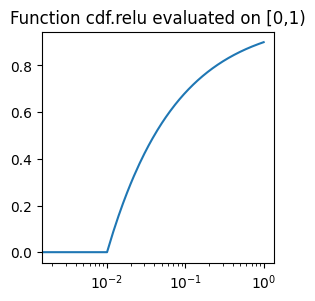

In [15]:
plot_on_uniform_grid(cdf.relu, 0.1, 'cdf.relu')

````python
# In hofa.cdf
def cutoff(eigvals : np.ndarray, epsilon : float)
````
This function does the operation $x\mapsto 1_{x\ge \varepsilon^2}$. As before, the idea is that when applied to $|\widehat{f}(\chi)|^2$ it is 1 only when $|\widehat{f}(\chi)|\ge \varepsilon$.

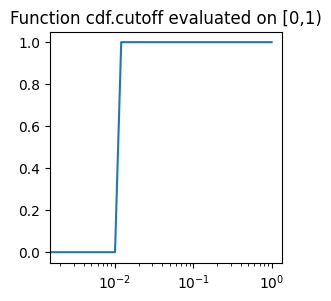

In [16]:
plot_on_uniform_grid(cdf.cutoff, 0.1, 'cdf.cutoff')

````python
# In hofa.cdf
def avg_cutoff(eigvals : np.ndarray, epsilon : float)
````
This function is an averaged version of the previous one over the interval $[\rho,2\rho]$. Hence, it equals $\mathbb{E}_{\varepsilon\in[\rho,2\rho]}1_{\sqrt{x}\ge \varepsilon}$. Equivalently, it is easy to deduce that it equals $\min\big(\tfrac{\sqrt{\max(\rho^2,x)}}{\rho}-1,1\big)$.

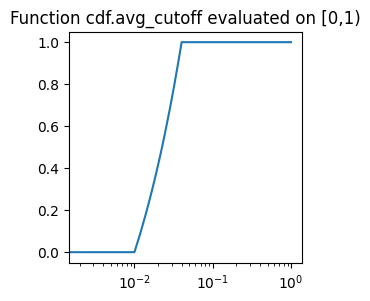

In [17]:
plot_on_uniform_grid(cdf.avg_cutoff, 0.1, 'cdf.avg_cutoff')

````python
# In hofa.cdf
def top_eig(eigvals : np.ndarray, n : int)
````
This function does not follow the pattern of the previous ones, as it does not assign a particular weight to the different eigenspaces but rather it masks for the top `n` eigenvalues. **Note** that a `StandardLayerRegularizer` class that uses it must also choose `mode='literal'` and provide such number.

````python
# In hofa.cdf
def u2_dual(eigvals : np.ndarray, unused : float)
````
Last but not least we have a function that corresponds to the $U^2$ dual operator. It turns out that this is probably the simplest of all, $x\mapsto x$ (the parameter `unused` is ignored). (Recall that we are putting a logaritmic scale in the $x$ axis, that is why we do not see a straight line.)

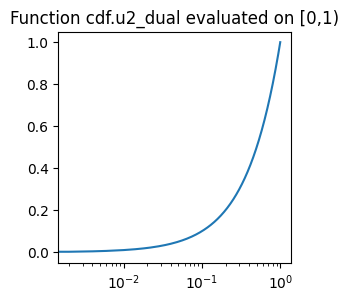

In [18]:
plot_on_uniform_grid(cdf.u2_dual, 0.1, 'cdf.u2_dual')

#### The `param` and `mode` parameters

As we just said, there is a parameter $\tau$ that each `StandardLayerRegularizer` object will use to pass to the `alpha_method` to compute the weights of the different eigenspaces. Suppose that a particular `StandardLayerRegularizer` object is called during `setup` with `depth`=$k$ and `layer`=$l$. Let `param`=$C$, let $f$ be the original function to regularize and let $\Delta_{t_1}\cdots\Delta_{t_{k-l-1}}f$ be the particular function the `StandardLayerRegularizer` object has to regularize of order $U^{l+1}$. The parameter $\tau$ will then be computed as follows.

* If `mode='literal'`, then $\tau = C$,
* If `mode='dynamic-original'` then $\tau = C\sigma^{2^{k-l-1}}\sqrt{\tfrac{\log |Z|}{|Z|}}$ where $\sigma^2 = \text{Var}(f) = \mathbb{E}_{x\in Z} |f-\mathbb{E}_{x\in Z}f|^2$.
* If `mode='dynamic-strict'` then $\tau = C\tilde{\sigma}\sqrt{\tfrac{\log |Z|}{|Z|}}$ where $\tilde{\sigma}^2 = \text{Var}(\Delta_{t_1}\cdots\Delta_{t_{k-l-1}}f)$.

The heuristic explanation behind these options will be detailed in a forthcoming paper.

#### The `lin_alg_method` and the `num_eigen` parameters

These are used to allow the user to choose between two different methods for obtaining the eigenvalues and eigenvectors of a matrix. Recall that if `layer`=0 during setup these values will be ignored and instead the Fast Fourier Transform will be used. The possibilities are as follows.

* If `lin_alg_method='full'` then this regularizer will use `numpy.linalg.eigh` as the method for obtaining the eigenvalue decomposition. In this case, the parameter `num_eigen` is ignored.
* If `lin_alg_method='sparse'` and `num_eigen` is an integer, then this regularizer will use the method `scipy.sparse.linalg.eigsh` with the number of eigenvalues being precisely the number passed in `num_eigen`.
* If `lin_alg_method='sparse'` and `num_eigen='dynamic'`, then this regularizer will use the method `scipy.sparse.linalg.eigsh` with the number of eigenvalues computed dynamically by the formula $\lfloor \tfrac{|Z|}{C^2\log|Z|}\rfloor$ where the constant ``param=``$C$ as in the previous section.

## Putting everything together: chirps

Having described the main components of the package and how they interact, we now illustrate their use on a concrete example with [chirps](https://en.wikipedia.org/wiki/Chirp). This section demonstrates how the ``regularize`` function performs in a larger, more complicated example. We will follow the same structure as in our [toy example at the beginning](#denoising--problem-statement) but with some changes.

### Problem statement

We want to transmit a convex combination of a **periodic** linear chirp of period $n=1001$ and a **non-periodic** linear chirp defined for $\{0,\ldots,n-1\}$.

$$f_s(x)=\tfrac{1}{2}\sin(200\pi x^2/n)+\tfrac{1}{2}\sin(5x^2/n)$$

defined for any integer $x\in\{0,\ldots,n-1\}$. Similarly as above, imagine that our communication channel introduces noise, and what is received is a convex combination $f=tf_r+(1-t)f_s$ where $f_r(x)$ follows a uniform distribution $\text{Unif}([-1,1))$ independently for every integer $x$ and the amount of noise is $t$, a parameter that we are going to vary in $[0,1)$.

### Objective

Under these assumptions, we aim to recover the function $f_s$ (or a close estimate of it).

This time, instead of using the default values of ``regularize``, let us use a different ``alpha_method``.

In [19]:
import moviepy as mpy
import os

output_folder = '_output'
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

N = 1001
output_video = '_output/tutorial_denoising.mp4'

def f_s(x : np.ndarray):
    return 0.5*np.sin(2*100*np.pi*x**2/N)+0.5*np.sin((5*x**2)/N)

# For the quadratic regularization we use now the average cutoff, and for computing the 
# eigendecomposition, we only use 6 dominant eigenvectors.
# We fix the random number generator for reproducibility.
list_reg = [
    rgz.StandardLayerRegularizer(alpha_method = cdf.avg_cutoff, rng = 28),
    rgz.StandardLayerRegularizer(alpha_method = cdf.avg_cutoff, rng = 28, num_eigen= 6)
]

### Strategy

Let us run the ``regualrize()`` function on the noisy version of $f_s$ for values of $t$ in $[0,1)$. The resulting function will be our candidate for recovery of $f_s$. Let us make a plot including the initial function to be recovered, the noisy version, and the regularized result in a video. You can find the video in the folder ``_output``.

In [20]:
x_values = np.arange(N)
rng = np.random.default_rng(123)
r_values = rng.uniform(-1, 1, size=len(x_values))
frames = 100

# Function to generate a frame
def generate_frame(t):

    print(f"t: {t:.2f}",end='\r')
    
    # Compute f(x) for the selected window
    y_values = (1 - t) * f_s(x_values)
    
    # Compute the modified function f_mod(x) = (1-t)*f(x) + t*r(x) using the same r_values
    y_values_mod = y_values + t * r_values

    # Regularize with respect to quadratic Fourier analysis
    y_values_quad_reg = rgz.regularize(y_values_mod,list_reg).regularization
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(12, 5))
    
    # Plot original function in light green with thin, semi-transparent lines and dots
    ax.plot(x_values, np.real(y_values), linestyle='-', color='lightgreen', marker='o', markersize=6, linewidth=1, alpha=0.6, label=fr'$(1-t)*f_s(x)$')
    
    # Plot modified function in red with thin, semi-transparent lines and dots
    ax.plot(x_values, np.real(y_values_mod), linestyle='-', color='red', marker='o', markersize=6, linewidth=1, alpha=0.6, label=r'$(1-t)f_s(x) + tf_r(x)$')

    # Plot recovered function with fourier analysis in yellow with thin, semi-transparent lines and dots
    ax.plot(x_values, np.real(y_values_quad_reg), linestyle='-', color='yellow', marker='o', markersize=3, linewidth=1, alpha=0.6, label=r'quadratic regularization')
    
    # Customize the plot
    ax.set_xlabel("x")
    l1_original = np.mean(np.abs(y_values))
    ax.set_title(f"t: {t:.2f}, \
    L1 original {l1_original:.5f},\
    L1 error quadratic reg. {np.mean(np.abs(y_values_quad_reg-y_values)):.5f}")
    ax.grid(True, linestyle="--", alpha=0.6)
    
    # Fix y-axis range and ticks from -1 to 1
    ax.set_ylim(-1, 1)
    ax.set_yticks(np.linspace(-1, 1, 5))  # Keeps y-axis ticks fixed at [-1, -0.5, 0, 0.5, 1]
    
    # Legend below the plot
    fig.subplots_adjust(bottom=0.25)  # Adjust layout to fit legend below
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=False)
    
    # Save frame as image
    filename = f"_output/frame_{t:.2f}.png"
    plt.savefig(filename)
    plt.close()
    return filename

# Generate frames
frame_files = [generate_frame(t / (frames - 1)) for t in range(frames)]

# Create movie
clip = mpy.ImageSequenceClip(frame_files, fps=10)
clip.write_videofile(output_video, codec='libx264')

# Remove individual frame images
for frame in frame_files:
    os.remove(frame)

print(f"Movie saved at {output_video}, individual frames deleted.")

MoviePy - Building video _output/tutorial_denoising.mp4.
MoviePy - Writing video _output/tutorial_denoising.mp4



MoviePy - Done !
MoviePy - video ready _output/tutorial_denoising.mp4
Movie saved at _output/tutorial_denoising.mp4, individual frames deleted.


<a id="denoising--coding-theory"></a>
## Putting everything together: coding theory

The previous example focused on the theory of chirps. In this section, we consider a different application that highlights the same algorithmic framework from a coding-theoretic perspective.

While the underlying workflow and API remain unchanged, this example emphasizes structural aspects that may be of particular interest to readers with a background in coding theory or discrete signal models. The goal is to illustrate how the general design presented above naturally accommodates this setting, without introducing additional mathematical machinery beyond what is strictly necessary.

### Problem statement

We want to transmit a function $\{0,1\}^{7}\to \{-1,1\}$ that can be expressed as a quadratic polynomial $\mathbb{F}_2^{7}\to \mathbb{C}$

$$f_s(x)= \exp( \pi i \sum_{i=0}^{5} x_ix_{i+1}).$$

Note that this functions equals $1$ when $\sum_{i=0}^{5} x_ix_{i+1}$ is even and $-1$ when $\sum_{i=0}^{5} x_ix_{i+1}$ is odd. Similar functions appear for example in the [Reed-Muller codes](https://en.wikipedia.org/wiki/Reed%E2%80%93Muller_code). 

Now imagine that we want to transmit the values of this function, but again out communication channel is noisy, and for a proportion $t\in[0,1)$ of the values, it swaps $1$ and $-1$ with probability $1/2$. Let us denote this noisy version of $f_s$ by $f$.

### Objective

Under these assumptions, for different values of $t$, we aim to compute an estimate of $f_s$.

In [21]:
import moviepy as mpy
import os
import itertools

output_video2 = '_output/tutorial_denoising2.mp4'

n = 7
f_s = np.empty([2]*n).astype(complex)

def quadratic_poly(x : np.ndarray):
    return np.exp(np.pi*1j*np.sum(x[:-1]*x[1:]))

for idx in itertools.product([0, 1], repeat=n):
    f_s[idx] = np.real(quadratic_poly(np.array(idx)))

Now we create the function $f$ for every $t$ between $0$ and $1$ and we regularize it using our algorithm. 

### Strategy

While our original signal takes either $1$ or $-1$, this is no longer the case for our regularized version. Thus, we may simply take the real part of our regularization and take 1 if the number is positive and -1 if it is negative. This is how we reconstruct our signal.

In [22]:
import random
import math

list_indices = list(itertools.product([0, 1], repeat=n))
M = len(list_indices)
rng = np.random.default_rng(4)
rng.shuffle(list_indices)
swapping_parameters = rng.integers(low = 0, high = 2, size = M)*2-1

frames = 100
x_values = range(M)

# Function to generate a frame
def generate_frame(t):

    print(f"t: {t:.2f}",end='\r')

    # We compute the noisy version of f_s
    elements_to_alter = math.floor(M*t)
    multipliers = np.ones_like(f_s)
    for i in range(elements_to_alter):
        multipliers[list_indices[i]] *= swapping_parameters[i]
    f = f_s*multipliers

    # Regularize with respect to quadratic Fourier analysis
    # Similarly as before, we fix the Random Number Generator for reproducibility
    y_values_quad_reg = np.sign(np.real(rgz.regularize(f,2, rng = 28).regularization))
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(12, 5))
    
    # Plot original function in light green with thin, semi-transparent lines and dots
    ax.plot(x_values, np.real(f_s.flatten()), linestyle=None, color='lightgreen', marker='o', markersize=6, linewidth=1, alpha=0.6, label=fr'$(1-t)*f_s(x)$')
    
    # Plot modified function in red with thin, semi-transparent lines and dots
    ax.plot(x_values, np.real(f.flatten()), linestyle=None, color='red', marker='o', markersize=6, linewidth=1, alpha=0.6, label=r'$(1-t)f_s(x) + tf_r(x)$')

    # Plot recovered function with fourier analysis in yellow with thin, semi-transparent lines and dots
    ax.plot(x_values, np.real(y_values_quad_reg.flatten()), linestyle=None, color='yellow', marker='o', markersize=3, linewidth=1, alpha=0.6, label=r'quadratic regularization')
    
    # Customize the plot
    ax.set_xlabel("x")
    l1_original = np.mean(np.abs(f_s))
    ax.set_title(f"Perfectage of elements randomly swapped with probability 1/2: {elements_to_alter/M*100:.2f}%, \
    Percentage of failed reconstruction: {100*np.sum(y_values_quad_reg!=f_s)/M:.2f}%")
    ax.grid(True, linestyle="--", alpha=0.6)
    
    # Fix y-axis range and ticks from -1 to 1
    ax.set_ylim(-1.1, 1.1)
    ax.set_yticks(np.linspace(-1, 1, 5))  # Keeps y-axis ticks fixed at [-1, -0.5, 0, 0.5, 1]
    
    # Legend below the plot
    fig.subplots_adjust(bottom=0.25)  # Adjust layout to fit legend below
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=False)
    
    # Save frame as image
    filename = f"_output/frame_{t:.2f}.png"
    plt.savefig(filename)
    plt.close()
    return filename

# Generate frames
frame_files = [generate_frame(t / (frames - 1)) for t in range(frames)]

# Create movie
clip = mpy.ImageSequenceClip(frame_files, fps=10)
clip.write_videofile(output_video2, codec='libx264')

# Remove individual frame images
for frame in frame_files:
    os.remove(frame)

print(f"Movie saved at {output_video2}, individual frames deleted.")

MoviePy - Building video _output/tutorial_denoising2.mp4.
MoviePy - Writing video _output/tutorial_denoising2.mp4



MoviePy - Done !
MoviePy - video ready _output/tutorial_denoising2.mp4
Movie saved at _output/tutorial_denoising2.mp4, individual frames deleted.


Check the video we have just created, where up to a $t=50$% of **randomly swapped parameters** (that means that on average we have changed $25$% of the values) we get a **perfect reconstruction**.

## Beyond chirps and polynomial phase functions: nilsequences

In [Theoretical Foundations and Extensions](theoretical_foundations_extensions), we mention that the higher-order components of a signal can involve the functions called **nilsequences**. 
Nilsequences are in some sense similar to polynomial phase functions, but are typically more complicated and cannot be represented in terms of the latter. In this last section, we illustrate this in the quadratic setting and show how the ``hofa`` package can still deal with such functions.


### An example involving the Heisenberg nilmanifold

As we discuss in [Theoretical Foundations and Extensions](theoretical_foundations_extensions), nilsequences on $\mathbb{Z}/n\mathbb{Z}$ are functions of the form $F(g(x))$ which extend the notion of Fourier characters and polynomial phase functions as follows: instead of a homomorphism (or polynomial map) from the abelian group into the circle group $\mathbb{R}/\mathbb{Z}$, the map $g$ is a so-called *polynomial map* from $\mathbb{Z}/n\mathbb{Z}$ into a more subtle space called a **nilmanifold**, namely a quotient space $G/\Gamma$ where $G$ is a nilpotent Lie group and $\Gamma$ is a lattice (discrete cocompact subgroup) in $G$. This map $g$ is composed with a continuous complex-valued function $F$ on $G/\Gamma$, which is required to have Lipschitz norm bounded independently of $n$. The **step** of such a nilsequence (and of the underlying nilmanifold) is the nilpotency class of the group $G$.

Let us immediately give an important **2-step example** of a nilmanifold (pertaining to quadratic Fourier analysis): the **Heisenberg nilmanifold**.

For this we define the Heisenberg group $G:=\left(\begin{matrix} 1 & \mathbb{R} & \mathbb{R}\\[0.1em]0  & 1 & \mathbb{R}\\[0.1em] 0 & 0 & 1 \end{matrix}\right)$, and the lattice $\Gamma:=\left(\begin{matrix} 1 & \mathbb{Z} & \mathbb{Z}\\[0.1em]0  & 1 & \mathbb{Z}\\[0.1em] 0 & 0 & 1 \end{matrix}\right)$, known as the discrete Heisenberg group.

The Heisenberg nilmanifold is the quotient space $G/\Gamma$. We can then construct a 2-step nilsequence by evaluating a Lipschitz function on points of an orbit in this nilmanifold.
Let us fist fix such an orbit: suppose for simplicity that $n$ is prime, let $r$ be an integer, and let 

$$g=\left(\begin{matrix} 1 & 2r/n & r/n^2\\[0.1em]0  & 1 & 1/n\\[0.1em] 0 & 0 & 1 \end{matrix}\right).$$


We can then consider the orbit $\{g^x\Gamma: x\in \mathbb{Z}\}$ in $G/\Gamma$. A simple calculation shows that $g^n\in \Gamma$ and therefore the map $x\in\mathbb{Z}\mapsto g^x\Gamma\in G/\Gamma$ is periodic with period $n$. Thus, if we compose this map with a Lipschitz function $F:G/\Gamma\to\mathbb{C}$, we obtain an $n$-periodic 2-step nilsequence. 

Now, for the sake of simplicity, instead of a Lipschitz function $F$, we are going to define a function $h:G/\Gamma\to\mathbb{C}$ such that the composition $h(g^x\Gamma)$ will take a very simple form *resembling* a quadratic phase function. For this, note first that every point $g\Gamma\in G/\Gamma$ can be represented by a matrix lying in the *fundamental domain* of the Heisenberg nilmanifold, namely a matrix in $G$ all of whose entries are in the interval $[0,1)$.
We then define $h(g\Gamma)$ to be the function $\exp(2\pi i \cdot)$ applied to the entry $(1,3)$ (i.e. the top-right entry) of this representative of $g\Gamma$. We thus obtain the $n$-*periodic* function

$$x\in\mathbb{Z}\mapsto h(g^x\Gamma).$$

Note that this function is not strictly speaking a nilsequence (it can be seen that $h$ is not a continuous function on the Heisenberg nilmanifold). However, it has the advantage of agreeing, on the set of integers $x=0,\ldots,n$, with the following simple function (as another straightforward calculation shows):

$$f_s:x\in\mathbb{Z}\mapsto \exp(2\pi i x^2/n^2).$$


Note that this function $f_s$ resembles a quadratic phase function, but note carefully that it is *not* $n$-periodic (compare $f_s(n+1)$ and $f_s(1)$). In fact, it can be shown that, when we identify the group $\mathbb{Z}/n\mathbb{Z}$ as a set with $[0,n-1]$, the function $f_s$ is not close (in $L^2(\mathbb{Z}/n\mathbb{Z})$, say) to any genuine quadratic phase function on this group, i.e. any function of the form $\exp(2\pi i (ax^2+bx+c)/n)$.
On the other hand, it can also be shown that $f_s$ has large $U^3$-norm on $\mathbb{Z}/n\mathbb{Z}$.

Thus, this concrete function $f_s$ on $[0,n-1]$ is an interesting example which has strong quadratic structure, resembles quadratic phase functions, but cannot be characterized (even approximated) by the latter, whereas it *can* very easily be matched on $[0,n-1]$ by a periodic function if we use the Heisenberg nilmanifold (namely the function $h(g^x\Gamma)$).

Let us now test our algorithm on this example.
### Problem statement

Similarly as we did with chirps, let $f_s$ be the above function on $[0,n-1]$, and let us modify it by taking a convex combination $f=tf_r+(1-t)f_s$, where $t\in[0,1)$ and $f_r(x)$ follows a uniform distribution $\text{Unif}([-1,1))$ independently for every integer $x$.

### Objective

Recover $f_s$ from the noisy version $f$.

In [23]:
import moviepy as mpy
import os

N = 1001
output_video = '_output/tutorial_denoising3.mp4'
t = 100

def f_s(x : np.ndarray):
    return np.exp(2*t*np.pi*1j*x**2/N**2)

In [24]:
x_values = np.arange(N)
rng = np.random.default_rng(123)
r_values = rng.uniform(-1, 1, size=len(x_values))
frames = 100

lower_limit_plot, upper_limit_plot = 200, 600

# Function to generate a frame
def generate_frame(t):

    print(f"t: {t:.2f}",end='\r')
    
    # Compute f(x) for the selected window
    y_values = (1 - t) * f_s(x_values)
    
    # Compute the modified function f_mod(x) = (1-t)*f(x) + t*r(x) using the same r_values
    y_values_mod = y_values + t * r_values

    # Regularize with respect to quadratic Fourier analysis
    y_values_quad_reg = rgz.regularize(y_values_mod,2).regularization
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(12, 5))
    
    # Plot original function in light green with thin, semi-transparent lines and dots
    ax.plot(x_values[lower_limit_plot:upper_limit_plot], np.real(y_values)[lower_limit_plot:upper_limit_plot], linestyle='-', color='lightgreen', marker='o', markersize=6, linewidth=1, alpha=0.6, label=fr'$(1-t)*f_s(x)$')
    
    # Plot modified function in red with thin, semi-transparent lines and dots
    ax.plot(x_values[lower_limit_plot:upper_limit_plot], np.real(y_values_mod)[lower_limit_plot:upper_limit_plot], linestyle='-', color='red', marker='o', markersize=6, linewidth=1, alpha=0.6, label=r'$(1-t)f_s(x) + tf_r(x)$')

    # Plot recovered function with fourier analysis in yellow with thin, semi-transparent lines and dots
    ax.plot(x_values[lower_limit_plot:upper_limit_plot], np.real(y_values_quad_reg)[lower_limit_plot:upper_limit_plot], linestyle='-', color='yellow', marker='o', markersize=3, linewidth=1, alpha=0.6, label=r'quadratic regularization')
    
    # Customize the plot
    ax.set_xlabel("x")
    l1_original = np.mean(np.abs(y_values))
    ax.set_title(f"t: {t:.2f}, \
    L1 original {l1_original:.5f},\
    L1 error quadratic reg. {np.mean(np.abs(y_values_quad_reg-y_values)):.5f}")
    ax.grid(True, linestyle="--", alpha=0.6)
    
    # Fix y-axis range and ticks from -1 to 1
    ax.set_ylim(-1, 1)
    ax.set_yticks(np.linspace(-1, 1, 5))  # Keeps y-axis ticks fixed at [-1, -0.5, 0, 0.5, 1]
    
    # Legend below the plot
    fig.subplots_adjust(bottom=0.25)  # Adjust layout to fit legend below
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=False)
    
    # Save frame as image
    filename = f"_output/frame_{t:.2f}.png"
    plt.savefig(filename)
    plt.close()
    return filename

# Generate frames
frame_files = [generate_frame(t / (frames - 1)) for t in range(frames)]

# Create movie
clip = mpy.ImageSequenceClip(frame_files, fps=10)
clip.write_videofile(output_video, codec='libx264')

# Remove individual frame images
for frame in frame_files:
    os.remove(frame)

print(f"Movie saved at {output_video}, individual frames deleted.")

MoviePy - Building video _output/tutorial_denoising3.mp4.
MoviePy - Writing video _output/tutorial_denoising3.mp4



MoviePy - Done !
MoviePy - video ready _output/tutorial_denoising3.mp4
Movie saved at _output/tutorial_denoising3.mp4, individual frames deleted.
